# Data Preprocessing

In [1]:
from src.data_preprocessing import (
    read_oscilloscope_data, 
    process_time_series,
    load_data_from_directory,
    extract_and_normalize_peak_segments,
    plot_random_segments
)

from src.utils import move_random_csv_files, rename_folder, plot_spectrum
import pandas as pd


%load_ext autoreload
%autoreload 2

## Anomalous data

<Axes: xlabel='Time'>

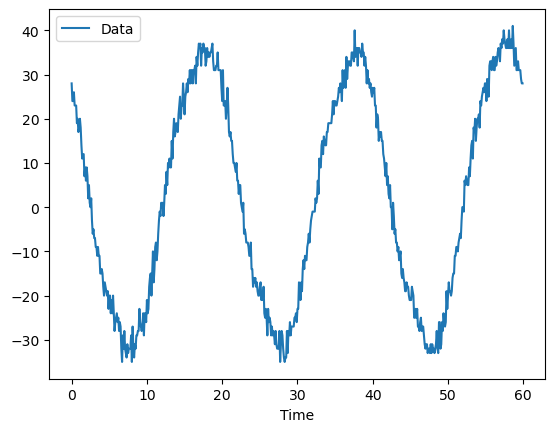

In [2]:
# Read raw data
df = read_oscilloscope_data(
    file_path='../data/raw/0702  межвитковые фазы A ток фазы А.txt',
    output_path='../data/processed/Anomalous.csv'
    )

df[:600].plot(x='Time', y='Data')

In [3]:
# Process time series
process_time_series(
    input_data=df, 
    output_dir='../data/processed/Final_Anomalous', 
    f_sampling=10000, 
    db=True
)

Results saved to ../data/processed/Final_Anomalous


In [4]:
# Load processed data
fft_data = load_data_from_directory(directory='../data/processed/Final_Anomalous')

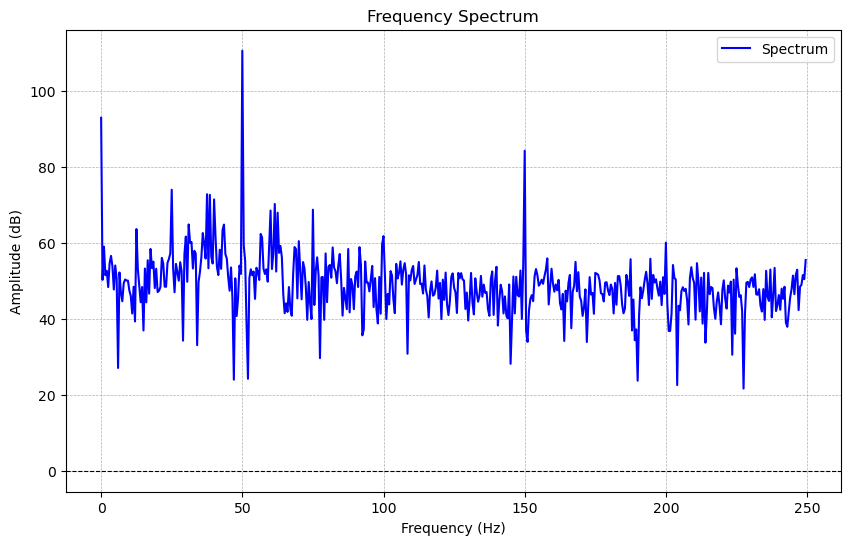

In [5]:
plot_spectrum(pd.read_csv('../data/processed/Final_Anomalous/Window_1.csv'))

In [6]:
# Extract and normalize peak segments
segment_length = 6
target_frequency = 150

normalized_peak_segments, minmax_stats = extract_and_normalize_peak_segments(
    fft_data, 
    segment_length=segment_length, 
    target_frequency=target_frequency, 
    method='min-max'
)

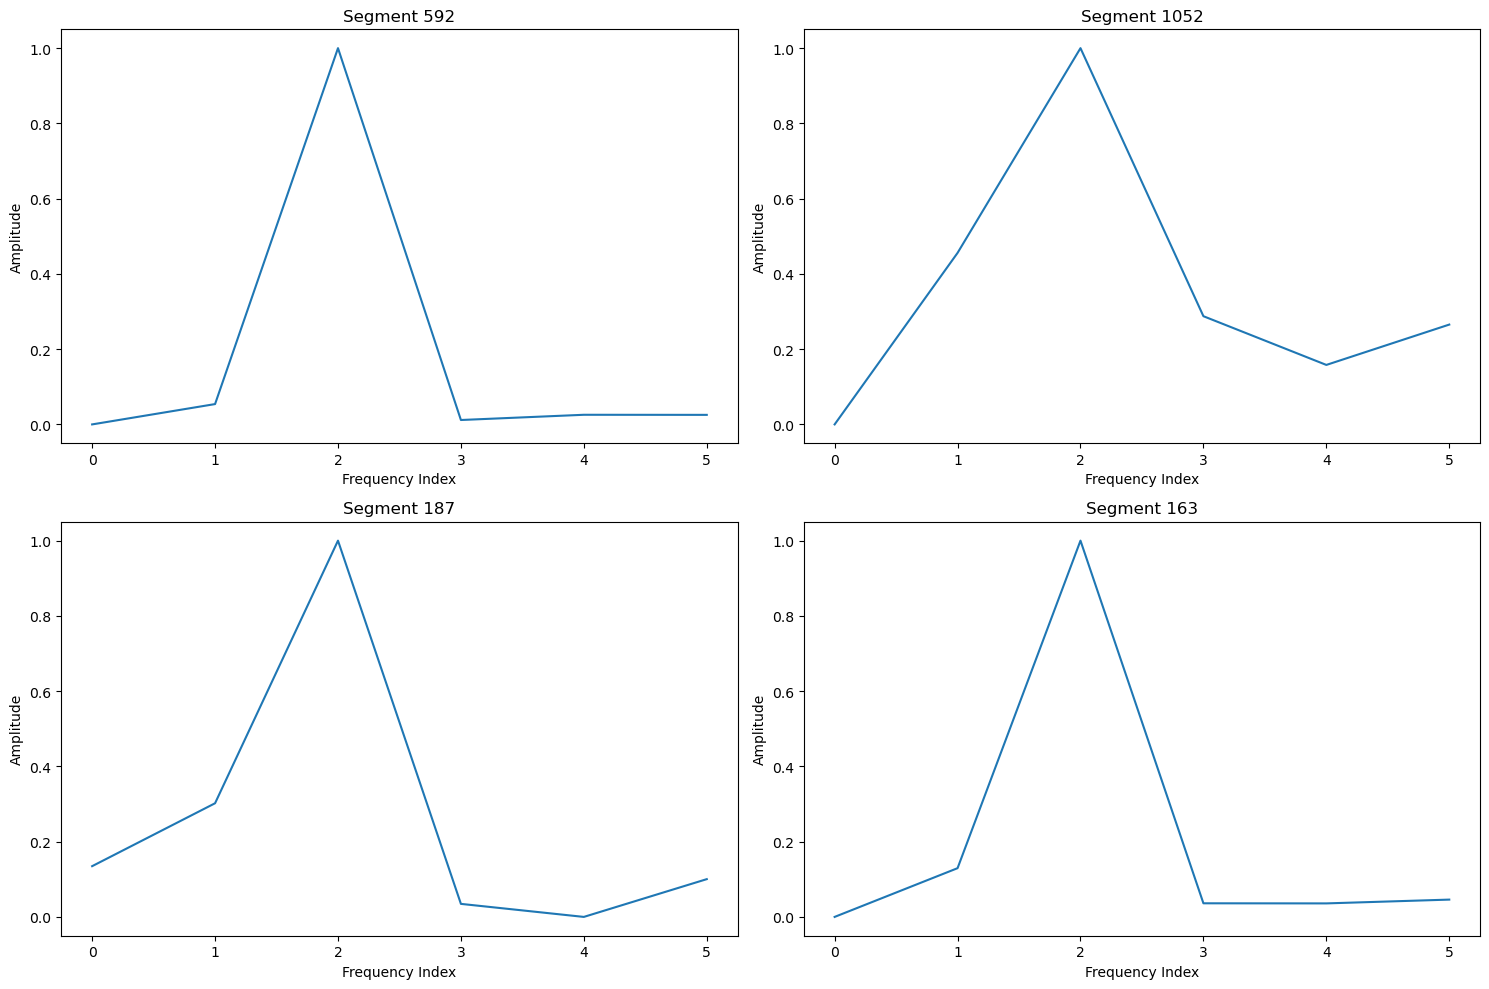

In [7]:
# Plot segments
plot_random_segments(normalized_peak_segments, num_segments=4)

## Normal and Candidates for Augmentation Data

In [8]:
# Read raw data
df = read_oscilloscope_data(
    file_path='../data/raw/0702 без перекосов фаза A.txt',
    output_path='../data/processed/Normal.csv'
    )

In [9]:
# Process time series
process_time_series(
    input_data='../data/processed/Normal.csv', 
    output_dir='../data/processed/Normal_and_Candidates_for_Augmentation', 
    f_sampling=10000, 
    db=True
)

Results saved to ../data/processed/Normal_and_Candidates_for_Augmentation


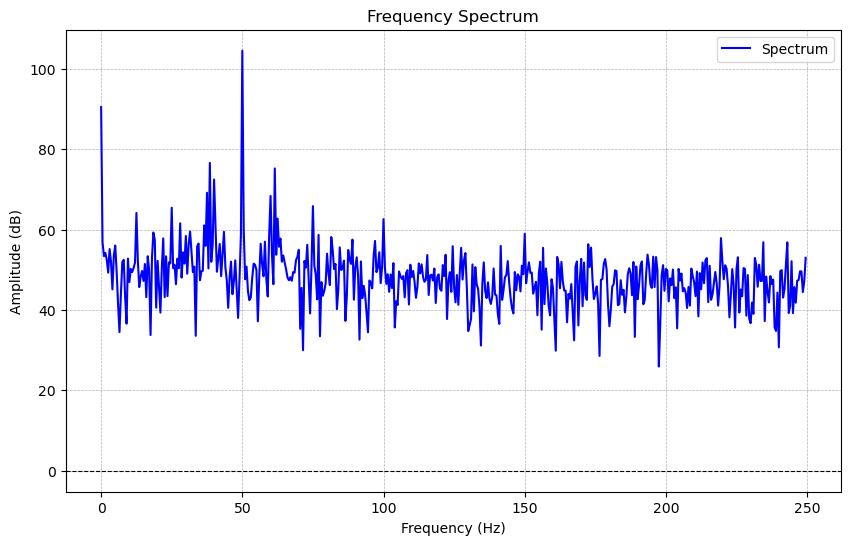

In [11]:
plot_spectrum(pd.read_csv('../data/processed/Normal_and_Candidates_for_Augmentation/Window_1.csv'))

In [12]:
n_candidates = 1500

_ = move_random_csv_files(
    input_dir='../data/processed/Normal_and_Candidates_for_Augmentation',
    output_dir='../data/processed/Candidates_for_Augmentation',
    n_files=n_candidates
)

rename_folder(
    current_folder_path='../data/processed/Normal_and_Candidates_for_Augmentation',
    new_folder_path='../data/processed/Final_Normal'
)

"An error occurred: [Errno 66] Directory not empty: '../data/processed/Normal_and_Candidates_for_Augmentation' -> '../data/processed/Final_Normal'"